## Cross-modal Multimodal RAG = using one type of data as a query to retrieve relevant information in another type of data.

# End-to-End Cross-modal Multimodal RAG  with Google Gemini, LangChain & FAISS

This notebook demonstrates how to build a complete **Multimodal Retrieval-Augmented Generation (Multimodal RAG)** system using **Google Gemini 3.5 Flash**, **LangChain**, **HuggingFace Embeddings**, and **FAISS**.

Instead of storing raw images directly, the system first uses **Google Gemini 3.5 Flash** to analyze an image and generate a detailed textual description. That description becomes the knowledge source for Retrieval-Augmented Generation (RAG), where it is chunked, embedded, stored in a FAISS vector database, and retrieved to answer user questions with relevant context.

Think of it as showing a product image to an AI assistant. The assistant first understands what it sees, converts that understanding into searchable text, looks up the most relevant information from its knowledge base, and finally generates an accurate, context-aware response.

## What this notebook covers

1. Install the required Python packages
2. Import the required libraries
3. Configure the Google Gemini API key
4. Load the Gemini text model
5. Test the Gemini text model
6. Download and display a product image
7. Generate a detailed image description using Google Gemini 3.5 Flash
8. Save the generated description as a text file
9. Load the text file using LangChain's TextLoader
10. Split the document into chunks
11. Generate embeddings using **BAAI/bge-base-en-v1.5**
12. Store embeddings in a **FAISS Vector Database**
13. Create a semantic retriever
14. Build a Retrieval-Augmented Generation (RAG) chain
15. Test the RAG pipeline with text queries
16. Test the complete Multimodal RAG pipeline using a new image

Each section contains a brief explanation followed by the implementation code, making it easy to understand how image understanding, semantic retrieval, and large language models work together to build a complete Multimodal RAG system.

## Step 1: Install the required libraries

Before writing any code we need a few Python packages.

Langchain is the framework that lets us chain together language models, prompts, retrievers and vector stores instead of wiring everything by hand.
langchain google genai is the connector package that lets Langchain talk to Google's Gemini models.
The docarray extra of langchain gives us an easy in memory document format to experiment with.
faiss cpu is a fast similarity search library from Facebook AI Research, used here to store and search text embeddings.
pypdf is included so the same environment can also read PDF files if needed later.

Run the cell below once per environment. In Google Colab this installs the packages into the current session.

In [ ]:
%pip install --upgrade langchain langchain-google-genai "langchain[docarray]" faiss-cpu pypdf


## Step 2: Import the libraries we will use

The imports are grouped by purpose so it is easy to see what each one is for.

os and requests handle environment variables and downloading files from the internet.
Pillow (PIL) is used to open and display images.
matplotlib and IPython.display are used purely for showing images and nicely formatted markdown output inside the notebook, they are not part of the RAG logic itself.

In [1]:
import os
import requests
from PIL import Image


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown


Next we bring in the pieces that talk to Gemini itself.

ChatGoogleGenerativeAI is the chat model wrapper that lets Langchain call Gemini for both text and vision tasks.
HumanMessage and SystemMessage are Langchain's way of representing a chat turn, and they also support mixed content such as text plus an image in the same message.

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI


f:\Multimodal-RAG-Systems\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage


These next imports cover the retrieval side of the pipeline: an in memory vector store option, the embedding model, prompt and output handling utilities, document loaders, a text splitter, and the FAISS vector store we will actually use to hold our product descriptions.

In [6]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings


In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate


In [9]:
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader


In [10]:
from langchain_text_splitters import CharacterTextSplitter


In [11]:
from langchain_community.vectorstores import FAISS


## Step 3: Set up the Google API key

Gemini models are accessed through an API key generated in Google AI Studio.
In Colab, the key is stored securely using the built in userdata secrets manager rather than being typed directly into the notebook, which keeps it out of the notebook file itself.
The key is then placed into an environment variable named GOOGLE_API_KEY, which is the variable name that langchain_google_genai looks for automatically.

In [12]:
import os
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# Read the API key
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# Make it available to Google GenAI SDK
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY


## Step 4: A small helper to load either a text model or a vision model

Gemini exposes separate model names for pure text tasks and for tasks that include images. Rather than repeating the same setup code twice, this helper function takes a model name and returns the matching chat model object.

Note that gemini pro and gemini pro vision were the original Gemini 1.0 model names used when this workflow was first put together. Google has since introduced newer model versions such as the Gemini 1.5 and 2.x family, so if this cell errors out with a model not found message, swap in whichever current model name Google AI Studio lists for text and for vision at the time you run this.

In [51]:
from langchain_google_genai import ChatGoogleGenerativeAI

def load_model(model_name):
    return ChatGoogleGenerativeAI(
        model=model_name,
        temperature=0
    )

## Step 5: Load and test the text model

First we load the plain text model and give it a light hearted prompt just to confirm the connection works end to end.

In [32]:
model_text = load_model("gemini-3.1-flash-lite")


In [33]:
# Quick sanity check: ask the model for a joke and read the text of its reply
response = model_text.invoke("Tell me a joke")

print(response.content)


[{'type': 'text', 'text': "Why don't scientists trust atoms?\n\nBecause they make up everything!", 'extras': {'signature': 'EjQKMgERTTIPF5XZ12/+wxUjmJ3/e/cZq3DRNDyyXODlkTI5GHOuLlVd2061p220tU5mOU2b'}}]


In [34]:
response = model_text.invoke("Tell me a joke")

print(response.content[0]["text"])

Why don't scientists trust atoms?

Because they make up everything!


In [36]:
# A second check using the HumanMessage format, which is the same structure
# we will reuse later for image plus text prompts
from langchain_core.messages import HumanMessage

response = model_text.invoke(
    [
        HumanMessage(
            content="Answer with Simple 'Yes' or 'No'. Question: Is apple a Fruit?"
        )
    ]
)

print(response.content)

[{'type': 'text', 'text': 'Yes.', 'extras': {'signature': 'EjQKMgERTTIPerMBDY0Sp5L3wPMIxfzym/3ul73onzv+HvjMgSLsbQZOFe+JOZdiD+Sb6r+f'}}]


In [38]:
response = model_text.invoke(
    "Answer with Simple 'Yes' or 'No'. Question: Is apple a Fruit?"
)

print(response.content[0]["text"])

Yes.


## Step 6: Download and display a product image

Before the vision model can describe a product, we need an actual image to hand it. This helper function downloads an image from a URL, saves it locally, and opens it with Pillow so it can be shown in the notebook and passed to the model.

This function only:

1. Downloads the image from the URL.
2. Saves it locally.
3. Opens it with PIL.
4. Returns a `PIL.Image.Image` object.

In [40]:
import os
import requests
from PIL import Image

def get_image(url, filename, extension):
    """
    Download an image and save it inside:
    <current_project>/data/images/
    """

    # Current project directory
    project_dir = os.getcwd()

    # Create data/images if it doesn't exist
    image_dir = os.path.join(project_dir, "data", "images")
    os.makedirs(image_dir, exist_ok=True)

    # Full image path
    image_path = os.path.join(image_dir, f"{filename}.{extension}")

    # Download image
    response = requests.get(url)
    response.raise_for_status()

    # Save image
    with open(image_path, "wb") as f:
        f.write(response.content)

    # Open image
    image = Image.open(image_path)

    print(f"Image saved at: {image_path}")

    return image

In [41]:
# Download a Nike Dunk Low product photo
image = get_image(
    "https://static.nike.com/a/images/t_PDP_1728_v1/f_auto,q_auto:eco/1705ca64-fbc8-4b79-a451-4ab77760c219/dunk-low-older-shoes-C7T1cx.png",
    "nike-shoes",
    "png"
)


Image saved at: f:\Multimodal-RAG-Systems\Multimodal_RAG_with_Gemini\data\images\nike-shoes.png


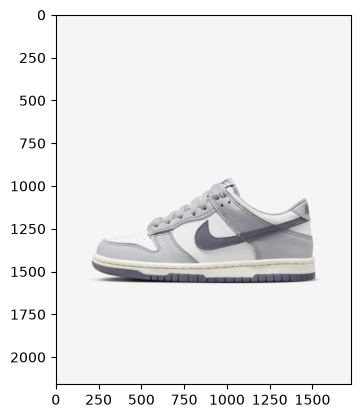

In [42]:
# Display the image inline in the notebook
plt.imshow(image)
plt.show()


## Step 7: Use the vision model to describe the image

Now we load the vision capable model and ask it to summarize the picture in just a few words. This is the multimodal part of multimodal RAG: the model receives both a text instruction and an image inside the same HumanMessage.

Step 1: Create the Gemini Client

In [52]:
from google import genai
import os

client = genai.Client(
    api_key=os.getenv("GOOGLE_API_KEY")
)

## Why use Google GenAI SDK instead of LangChain for Vision?

For text-only applications such as chatbots, RAG, and prompt chaining, LangChain's `ChatGoogleGenerativeAI` works very well.

However, for **multimodal inference (text + image)**, we use the **Google GenAI SDK** because it is Google's official SDK and provides the latest support for Gemini's multimodal capabilities.

### Why Google GenAI SDK?

- Official SDK maintained by Google.
- Supports the latest Gemini models (Gemini 3.5 Flash, Gemini 3.5 Pro, etc.).
- Accepts `PIL.Image` objects directly without converting them to Base64.
- Simpler API with fewer lines of code.
- Compatible with the latest Gemini multimodal features.

### Why not LangChain for Vision?

The notebook was originally written for the deprecated **Gemini Pro Vision** model. Recent versions of LangChain and Gemini have changed the multimodal message format, making older examples incompatible with the latest SDK versions.

LangChain is still an excellent choice for:

- Text generation
- Prompt templates
- Chains
- Agents
- RAG pipelines

For image understanding, the Google GenAI SDK is currently the simplest and most reliable approach.

Step 2: Define the Prompt

In [53]:
prompt = "Give me summary of this image in 5 words."

Step 3: Invoke Gemini with Text + Image

In [54]:
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[
        prompt,
        image
    ]
)

print(response.text)

Grey and white Nike shoe.


## LangChain vs Google GenAI SDK

| LangChain | Google GenAI SDK |
|-----------|------------------|
| `invoke()` | `generate_content()` |
| `ChatGoogleGenerativeAI()` | `genai.Client()` |
| `HumanMessage()` | `contents=[prompt, image]` |

## Generate a Text Description from an Image

Before storing an image in a Vector Database, we first convert it into a **rich textual description** using Gemini.

Large Language Models can understand images, but Vector Databases store and retrieve **text embeddings** more effectively. Therefore, we ask Gemini to analyze the image and generate a detailed description containing all important visual information.

The generated description is then saved as a text file (`nike_shoes.txt`), which can later be:

- Loaded using `TextLoader`
- Split into chunks
- Converted into embeddings
- Stored in a Vector Database (e.g., LanceDB)
- Retrieved during the RAG pipeline

This approach allows the retrieval system to understand image content through its textual representation, making image search more accurate and semantically meaningful.

In [56]:
import os
from google import genai

# Create the Gemini client
client = genai.Client(
    api_key=os.getenv("GOOGLE_API_KEY")
)

# Prompt for generating a rich image description
prompt = """
You are an expert product analyst.

Analyze the given image and generate a comprehensive description.

Include the following information:

- Product Name
- Brand
- Category
- Primary Colors
- Secondary Colors
- Material
- Design
- Visible Logo
- Background
- Objects Present
- Possible Use
- Detailed Description

If any information is not visible in the image, return:
"Not visible in the image."

Do not guess or hallucinate missing information.
"""

# Generate the description
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[
        prompt,
        image
    ]
)

# Extract generated text
image_description = response.text

# Create output directory if it doesn't exist
output_dir = os.path.join(os.getcwd(), "data")
os.makedirs(output_dir, exist_ok=True)

# Save description to a text file
text_file = os.path.join(output_dir, "nike_shoes.txt")

with open(text_file, "w", encoding="utf-8") as file:
    file.write(image_description)

print(f"Image description saved to: {text_file}")

Image description saved to: f:\Multimodal-RAG-Systems\Multimodal_RAG_with_Gemini\data\nike_shoes.txt


```text
                    Image
                      │
                      ▼
        Gemini 3.5 Flash (Vision Model)
          (Generates Image Description)
                      │
                      ▼
       Detailed Image Description (Text)
                      │
                      ▼
              nike_shoes.txt
                      │
                      ▼
                 TextLoader
             (Loads Text File)
                      │
                      ▼
             Text Chunking/Splitting
                      │
                      ▼
          Embedding Model
    (Converts Text into Vectors)
                      │
                      ▼
       LanceDB (Vector Database)
                      │
                      ▼
     Multimodal RAG Retrieval
```

## Step 8: Load the Product Description Text

The retrieval component of a Multimodal RAG system searches over textual knowledge rather than raw images.

In the previous step, Gemini analyzed the product image and generated a detailed textual description, which was saved as **`nike_shoes.txt`**.

In this step, we load that text file using LangChain's `TextLoader`. The loaded document will later be:

- Split into smaller chunks
- Converted into vector embeddings
- Stored in LanceDB
- Retrieved during the RAG pipeline to answer user questions

This converts the image into searchable textual knowledge that can be efficiently indexed and retrieved.

In [58]:
from langchain_community.document_loaders import TextLoader
import os

# Path to the generated product description
text_path = os.path.join(os.getcwd(), "data", "nike_shoes.txt")

# Load the text file as a LangChain Document
loader = TextLoader(text_path)

documents = loader.load()


In [59]:
# Display the loaded content
print(documents[0].page_content)


Based on the image provided, here is a comprehensive product analysis:

*   **Product Name:** Nike Dunk Low (Specific colorway edition name is not printed or visible in the image).
*   **Brand:** Nike
*   **Category:** Footwear / Sneakers
*   **Primary Colors:** White, Light Grey
*   **Secondary Colors:** Dark purplish-grey (slate), Cream/Off-white
*   **Material:** Leather upper, textile laces/lining, and rubber sole.
*   **Design:** Classic low-top sneaker featuring a paneled leather upper, a perforated toe box for breathability, a stitched midsole, and a textured rubber outsole. 
*   **Visible Logo:** The iconic Nike Swoosh in dark purplish-grey on the side, with "NIKE" branding partially visible on the tongue tag and the heel tab.
*   **Background:** Solid, clean off-white/light-grey studio background.
*   **Objects Present:** A single left-foot shoe shown from its lateral side profile.
*   **Possible Use:** Casual everyday wear, streetwear fashion, and skateboarding.
*   **Detaile

## Step 9: Split the Text into Chunks

Embedding models perform better when they process smaller, meaningful sections of text rather than one long document.

In this step, we split the product description into overlapping chunks using LangChain's `CharacterTextSplitter`.

Each chunk is converted into a LangChain `Document` object, which will later be embedded and stored in LanceDB.

Using overlapping chunks helps preserve context between neighboring chunks, reducing the chance of losing important information at chunk boundaries.

In [61]:
from langchain_text_splitters import CharacterTextSplitter
from langchain_core.documents import Document


def get_text_chunks_langchain(text):
    """
    Split the product description into smaller overlapping chunks
    and convert each chunk into a LangChain Document.
    """

    text_splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=300,
        chunk_overlap=50,
        length_function=len,
    )

    chunks = text_splitter.split_text(text)

    docs = [Document(page_content=chunk) for chunk in chunks]

    return docs


In [62]:
# Split the loaded text into chunks
docs = get_text_chunks_langchain(documents[0].page_content)

print(f"Number of chunks: {len(docs)}")
print(docs[0].page_content)

Number of chunks: 6
Based on the image provided, here is a comprehensive product analysis:
*   **Product Name:** Nike Dunk Low (Specific colorway edition name is not printed or visible in the image).
*   **Brand:** Nike
*   **Category:** Footwear / Sneakers
*   **Primary Colors:** White, Light Grey


## Step 10: Generate Embeddings and Store Them in FAISS

Embedding models convert text into dense numerical vectors that capture the semantic meaning of the text.

Instead of using Google's embedding API, we use the open-source **BAAI/bge-base-en-v1.5** embedding model from Hugging Face.

Benefits of using a local embedding model:

- Completely free
- No API quota limits
- Runs locally
- High-quality semantic embeddings
- Ideal for Retrieval-Augmented Generation (RAG)

After generating embeddings for every text chunk, we store them in a **FAISS** vector database.

FAISS enables fast similarity search by comparing the embedding of a user's query with the embeddings of all stored document chunks and retrieving the most relevant ones.

In [64]:
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Load Hugging Face API Token (Optional)
HF_TOKEN = os.getenv("HF_TOKEN")

print("Hugging Face Token Loaded:", HF_TOKEN is not None)

Hugging Face Token Loaded: True


In [65]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# Load the embedding model
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1999.44it/s]


In [66]:
# Build the FAISS index directly from the chunked documents and their embeddings
vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embeddings
)

print("✅ FAISS Vector Store created successfully!")

✅ FAISS Vector Store created successfully!


## Step 11: Create a retriever and test it

A retriever is a simple wrapper around the vector store that takes a natural language query, embeds it the same way, and returns the most similar stored chunks. We test it here with a plain query about Nike slides and sandals to confirm it pulls back relevant text.

In [70]:
# Create a retriever from the FAISS vector store
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)


In [71]:
retriever.invoke("Nike slide/sandal.")


[Document(metadata={}, page_content='*   **Design:** Classic low-top sneaker featuring a paneled leather upper, a perforated toe box for breathability, a stitched midsole, and a textured rubber outsole.'),
 Document(metadata={}, page_content='Based on the image provided, here is a comprehensive product analysis:\n*   **Product Name:** Nike Dunk Low (Specific colorway edition name is not printed or visible in the image).\n*   **Brand:** Nike\n*   **Category:** Footwear / Sneakers\n*   **Primary Colors:** White, Light Grey'),
 Document(metadata={}, page_content='*   **Objects Present:** A single left-foot shoe shown from its lateral side profile.\n*   **Possible Use:** Casual everyday wear, streetwear fashion, and skateboarding.')]

In [69]:
query = "Which brand is this product?"

results = retriever.invoke(query)

for i, doc in enumerate(results, 1):
    print(f"\nResult {i}")
    print("-" * 50)
    print(doc.page_content)


Result 1
--------------------------------------------------
Based on the image provided, here is a comprehensive product analysis:
*   **Product Name:** Nike Dunk Low (Specific colorway edition name is not printed or visible in the image).
*   **Brand:** Nike
*   **Category:** Footwear / Sneakers
*   **Primary Colors:** White, Light Grey

Result 2
--------------------------------------------------
*   **Visible Logo:** The iconic Nike Swoosh in dark purplish-grey on the side, with "NIKE" branding partially visible on the tongue tag and the heel tab.
*   **Background:** Solid, clean off-white/light-grey studio background.

Result 3
--------------------------------------------------
*   **Design:** Classic low-top sneaker featuring a paneled leather upper, a perforated toe box for breathability, a stitched midsole, and a textured rubber outsole.


## Step 12: Build the Retrieval-Augmented Generation (RAG) Chain

This is where retrieval and generation are combined into a single pipeline.

When a user asks a question:

1. The query is converted into an embedding.
2. The retriever searches FAISS for the most relevant document chunks.
3. The retrieved chunks are inserted into the prompt as context.
4. Gemini receives both the retrieved context and the user's question.
5. Gemini generates an answer grounded in the retrieved information.
6. The output is converted into plain text for display.

This Retrieval-Augmented Generation (RAG) pipeline helps reduce hallucinations by ensuring the LLM answers using information retrieved from the knowledge base instead of relying only on its pretrained knowledge.

In [73]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# Load the Gemini text model
llm_text = load_model("gemini-3.5-flash")

Prompt Template

In [74]:
template = """
You are a helpful AI assistant.

Use ONLY the retrieved context below to answer the user's question.

If the answer is not present in the context, reply:
"I couldn't find that information in the knowledge base."

Retrieved Context:
------------------
{context}

------------------

User Question:
{query}

Provide a clear, concise, and accurate answer.
"""

prompt = ChatPromptTemplate.from_template(template)

Build the RAG Chain

In [ ]:
# The RAG chain: retrieve relevant chunks, format them with the query into
# the prompt, send that to the text model, then parse the output into a string

rag_chain = (
    {
        "context": retriever,
        "query": RunnablePassthrough()
    }
    | prompt
    | llm_text
    | StrOutputParser()
)

## Step 13: Query the RAG Pipeline

The Retrieval-Augmented Generation (RAG) pipeline is now ready to answer questions.

When a user submits a question:

1. The query is converted into an embedding.
2. FAISS retrieves the most relevant document chunks.
3. The retrieved context is inserted into the prompt.
4. Gemini generates an answer using only the retrieved context.
5. The final response is returned to the user.

This demonstrates how retrieval and generation work together to produce accurate, context-aware answers.

In [76]:
from IPython.display import Markdown, display

query = "Describe the Nike shoe in detail."

result = rag_chain.invoke(query)


In [77]:

display(Markdown(result))

Based on the provided context, here is a detailed description of the Nike Dunk Low sneaker:

*   **Design & Structure:** It is a classic low-top sneaker featuring a paneled leather upper, a perforated toe box for breathability, a stitched midsole, and a textured rubber outsole.
*   **Upper Base:** Features a smooth white leather base on the toe box, mid-panel, and collar.
*   **Overlays:** Light grey leather overlays cover the toe cap, lace stays, and heel.
*   **Swoosh:** A textured, dark purplish-grey leather Swoosh stretches across the side panel towards the heel.
*   **Laces:** The shoe is tied with flat grey laces that match the light grey overlays.
*   **Midsole:** An off-white/cream midsole with tonal stitching.
*   **Outsole:** A dark purplish-grey rubber outsole that matches the color of the Swoosh.

In [78]:
# Inspect the chain object itself to see how the pieces are connected
rag_chain


{
  context: VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000002303930ACD0>, search_kwargs={'k': 3}),
  query: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\nYou are a helpful AI assistant.\n\nUse ONLY the retrieved context below to answer the user\'s question.\n\nIf the answer is not present in the context, reply:\n"I couldn\'t find that information in the knowledge base."\n\nRetrieved Context:\n------------------\n{context}\n\n------------------\n\nUser Question:\n{query}\n\nProvide a clear, concise, and accurate answer.\n'), additional_kwargs={})])
| ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.7'

## Step 14: Build the Complete Multimodal RAG Pipeline

In the previous steps, we built a text-based Retrieval-Augmented Generation (RAG) pipeline.

Now we extend it to support **multimodal inputs** by allowing users to provide an image instead of a text query.

The complete pipeline works in two stages:

1. **Image Understanding:** Gemini 3.5 Flash analyzes the input image and generates a detailed textual description.
2. **Retrieval-Augmented Generation:** The generated description is used as the search query for the RAG pipeline. The retriever searches the vector database for the most relevant document chunks, and Gemini generates the final answer using the retrieved context.

This approach combines image understanding with semantic retrieval, enabling users to ask questions directly from images.

```text
                Input Image
                     │
                     ▼
       Gemini 3.5 Flash (Vision)
     Generate Image Description
                     │
                     ▼
       Generated Text Description
                     │
                     ▼
             RAG Retriever
        (FAISS Similarity Search)
                     │
                     ▼
      Retrieved Document Chunks
                     │
                     ▼
          Prompt Template
(Context + User Question/Description)
                     │
                     ▼
        Gemini 3.5 Flash (Text)
                     │
                     ▼
             Final Response
```

In [ ]:
full_chain = (
    RunnablePassthrough() | llm_vision | StrOutputParser() | rag_chain
)


In [ ]:
# Inspect the composed chain
full_chain


## Step 15: Test the Complete Multimodal RAG Pipeline

Finally, we test the complete Multimodal RAG pipeline using a new product image.

Instead of manually typing a search query, Gemini first analyzes the image and generates a detailed textual description.

That description is automatically used as the retrieval query, allowing the system to search the vector database and generate a context-aware response.

This demonstrates the complete workflow from image input to Retrieval-Augmented Generation.

Download another image

Image saved at: f:\Multimodal-RAG-Systems\Multimodal_RAG_with_Gemini\data\images\nike_slides.png


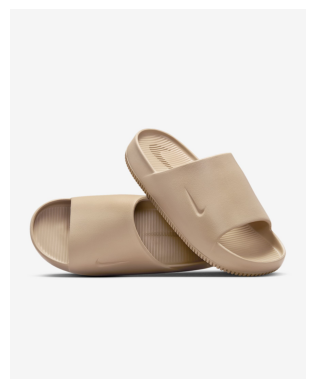

In [79]:
url = "https://static.nike.com/a/images/t_PDP_1728_v1/f_auto,q_auto:eco/252f2db6-d426-4931-80a0-8b7f8f875536/calm-slides-K7mr3W.png"

image = get_image(
    url,
    "nike_slides",
    "png"
)

plt.imshow(image)
plt.axis("off")
plt.show()

Generate an Image Description

In [ ]:
vision_prompt = """
Analyze this product image in detail.

Include:

- Product Name
- Brand
- Category
- Colors
- Material
- Design
- Visible Logo
- Intended Use

Write a detailed description.
"""

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[
        vision_prompt,
        image
    ]
)

image_description = response.text

print(image_description)

Pass the Description to the RAG Chain

In [ ]:
result = rag_chain.invoke(image_description)

display(Markdown(result))

## Conclusion

We successfully built a complete **Multimodal Retrieval-Augmented Generation (RAG)** pipeline that combines image understanding, semantic search, and large language models.

The workflow converts images into searchable text using **Google Gemini 3.5 Flash**, stores semantic embeddings in **FAISS**, retrieves the most relevant information using LangChain, and generates accurate responses grounded in the retrieved context. This approach improves answer quality while reducing hallucinations by relying on retrieved knowledge instead of only the model's pretrained knowledge.

# Complete Workflow

```text
                  Input Image
                       │
                       ▼
         Google Gemini 3.5 Flash (Vision)
         (Analyze Image)
                       │
                       ▼
        Detailed Image Description
                       │
                       ▼
             Save as Text File
             (nike_shoes.txt)
                       │
                       ▼
              LangChain TextLoader
                       │
                       ▼
           CharacterTextSplitter
        (Split into Small Chunks)
                       │
                       ▼
     HuggingFace Embedding Model
      (BAAI/bge-base-en-v1.5)
                       │
                       ▼
            Vector Embeddings
                       │
                       ▼
         FAISS Vector Database
                       │
                       ▼
         Similarity Retriever
                       │
                       ▼
          Retrieved Context
                       │
                       ▼
          Prompt Template
 (Context + User Question/Image Description)
                       │
                       ▼
      Google Gemini 3.5 Flash (LLM)
                       │
                       ▼
             Final Response
```


# Key Takeaways

- Images are converted into detailed textual descriptions using Gemini.
- The generated text forms the searchable knowledge base.
- Documents are chunked and embedded into dense vectors.
- FAISS performs semantic similarity search over the stored embeddings.
- Retrieved context is supplied to Gemini through a RAG pipeline.
- The final response is generated using both retrieval and generation, producing accurate, context-aware answers.

This end-to-end workflow demonstrates how modern Multimodal RAG systems combine computer vision, semantic search, vector databases, and Large Language Models to answer questions from both text and image inputs.